In [27]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('GLAM-WMES-metricas-concursos.csv')

In [28]:
df

,Fecha,Duración (días),Evento,Países,Participantes,Usuarios nuevos,Elementos editados,Elementos nuevos,Web
0,03/07/2015,1,Colaboración con el editatón de Wikidata en Sa...,Sin datos,Sin datos,Sin datos,Sin datos,Sin datos,https://web.archive.org/web/20150919082048/htt...
1,15/04/2016,45,Participación en el concurso Europeana Art His...,30,61,Sin datos,846,Sin datos,https://www.wikidata.org/wiki/Wikidata:Europea...
2,21/05/2016,1,I Pentatlón Wikimedia,1,10,2,60,49,https://es.wikipedia.org/wiki/Wikipedia:Encuen...
3,20/05/2017,1,II Pentatlón Wikimedia,1,9,0,53,45,https://es.wikipedia.org/wiki/Wikipedia:Encuen...
4,29/11/2017,1,Editatón de Wikidata en el marco de la Global ...,1,6,0,350,0,https://www.wikidata.org/wiki/Wikidata:Events/...
5,24/02/2018,1,Datatón Cervantes,1,25,10,1189,0,https://www.wikidata.org/wiki/Wikidata:Events/...
6,21/05/2018,7,III Pentatlón Wikimedia,1,5,0,40,40,https://es.wikipedia.org/wiki/Wikipedia:Encuen...
7,18/10/2018,2,Hackatón Wikidata,Sin datos,Sin datos,Sin datos,Sin datos,Sin datos,https://www.wikidata.org/wiki/Wikidata:Sixth_B...
8,01/12/2018,1,Datatón Every Politician,Sin datos,Sin datos,Sin datos,Sin datos,Sin datos,NaN
9,01/05/2024,31,Concurso Coordinate Me,16,3228,1449,129102,15261,https://www.wikidata.org/wiki/Wikidata:Events/...


In [29]:
df.dtypes

Fecha                 object
Duración (días)        int64
Evento                object
Países                object
Participantes         object
Usuarios nuevos       object
Elementos editados    object
Elementos nuevos      object
Web                   object
dtype: object

In [36]:
df['Fecha'] = pd.to_datetime(df['Fecha'], format='mixed', errors='coerce')

In [38]:
df["Participantes"] = df["Participantes"].replace("Sin datos", 0)
df["Participantes"] = df["Participantes"].astype(int)

In [39]:
df

,Fecha,Duración (días),Evento,Países,Participantes,Usuarios nuevos,Elementos editados,Elementos nuevos,Web,Ano
0,2015-03-07,1,Colaboración con el editatón de Wikidata en Sa...,Sin datos,0,Sin datos,Sin datos,Sin datos,https://web.archive.org/web/20150919082048/htt...,2015
1,2016-04-15,45,Participación en el concurso Europeana Art His...,30,61,Sin datos,846,Sin datos,https://www.wikidata.org/wiki/Wikidata:Europea...,2016
2,2016-05-21,1,I Pentatlón Wikimedia,1,10,2,60,49,https://es.wikipedia.org/wiki/Wikipedia:Encuen...,2016
3,2017-05-20,1,II Pentatlón Wikimedia,1,9,0,53,45,https://es.wikipedia.org/wiki/Wikipedia:Encuen...,2017
4,2017-11-29,1,Editatón de Wikidata en el marco de la Global ...,1,6,0,350,0,https://www.wikidata.org/wiki/Wikidata:Events/...,2017
5,2018-02-24,1,Datatón Cervantes,1,25,10,1189,0,https://www.wikidata.org/wiki/Wikidata:Events/...,2018
6,2018-05-21,7,III Pentatlón Wikimedia,1,5,0,40,40,https://es.wikipedia.org/wiki/Wikipedia:Encuen...,2018
7,2018-10-18,2,Hackatón Wikidata,Sin datos,0,Sin datos,Sin datos,Sin datos,https://www.wikidata.org/wiki/Wikidata:Sixth_B...,2018
8,2018-01-12,1,Datatón Every Politician,Sin datos,0,Sin datos,Sin datos,Sin datos,NaN,2018
9,2024-01-05,31,Concurso Coordinate Me,16,3228,1449,129102,15261,https://www.wikidata.org/wiki/Wikidata:Events/...,2024


In [40]:
df['Ano'] = df['Fecha'].apply(lambda x: x.strftime('%Y'))

In [41]:
df.groupby(['Ano'])['Ano'].count()

Ano
2015    1
2016    2
2017    2
2018    4
2024    1
2025    1
2026    2
Name: Ano, dtype: int64

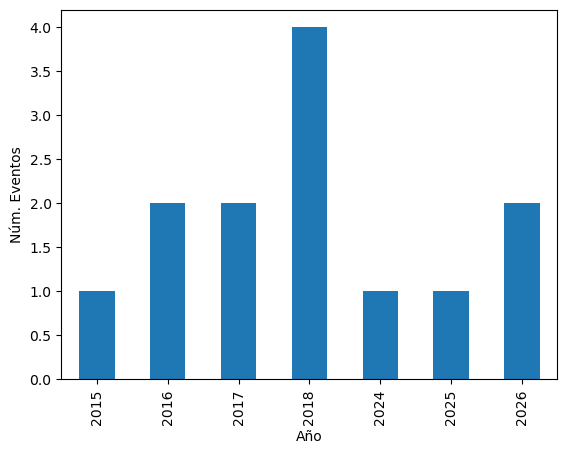

In [44]:
df.groupby(['Ano'])['Ano'].count().plot.bar()
plt.xlabel('Año')
plt.ylabel('Núm. Eventos');
plt.savefig("grafica-metricas.png", dpi=300, bbox_inches="tight")
plt.show()

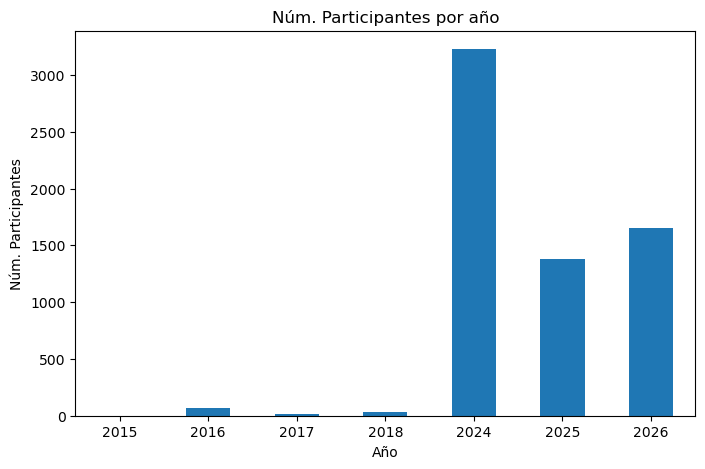

In [43]:
resultado = df.groupby(df["Ano"])["Participantes"].sum()

resultado.plot(kind="bar", figsize=(8, 5))

plt.xlabel("Año")
plt.ylabel("Núm. Participantes")
plt.title("Núm. Participantes por año")
plt.xticks(rotation=0)
plt.show()